In [19]:
# 1. import necessary library
import gzip
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import random
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import os
from adjustText import adjust_text


In [2]:
# 2. configure scanpy
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120)

In [20]:
# 3. set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [17]:
# 3. configure scanpy and paths
adata_path = "asd_brain.h5ad" 
senmayo_path = "../genes/Senmayo_genes/SAUL_SEN_MAYO.v2025.1.Hs.gmt" # SenMayo gene set
sc.settings.figdir = "../results/figures" 
FIG_DIR = "../results/figures"
TAB_DIR = "../results/tables"


In [12]:
# 4. load the data 
# exprMatrix.tsv.gz and meta.tsv previously was previously loaded, aligned, and saved to asd_brain.h5ad
# through running chunkread.ipynb
adata = sc.read_h5ad(adata_path)
print("Loaded AnnData:", adata.shape)

Loaded AnnData: (104559, 36501)


In [16]:
# 5. map Ensembl ID -> gene symbol

gtf_file = "../genes/gene_mapping/gencode.v49.primary_assembly.annotation.gtf.gz"
csv_file = "../genes/gene_mapping/gencode.v49.annotation.csv"

#parsing 
genes = []
with gzip.open(gtf_file, "rt", encoding="utf-8") as f:  # <-- use "rt"
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if parts[2] != "gene":
            continue
        attrs = parts[8]
        gene_id, gene_name = None, None
        for field in attrs.split(";"):
            field = field.strip()
            if field.startswith("gene_id"):
                gene_id = field.split('"')[1]
            elif field.startswith("gene_name"):
                gene_name = field.split('"')[1]
        if gene_id and gene_name:
            genes.append({"ensembl_id": gene_id, "gene_symbol": gene_name})

gmap = pd.DataFrame(genes).drop_duplicates("ensembl_id")
gmap["ensembl_id"] = gmap["ensembl_id"].str.replace(r"\.\d+$", "", regex=True)
gmap = gmap.set_index("ensembl_id")
gmap.to_csv(csv_file)

# remove Ensembl ID and preserve gene symbol only
adata.var_names = adata.var_names.astype(str).str.split("|").str[-1]

# remove version suffix if any remains in symbol
adata.var_names = adata.var_names.str.replace(r"\.\d+$", "", regex=True)

# ensure uniqueness
adata.var_names_make_unique()

print(f"Extracted {gmap.shape[0]} genes → {csv_file}")
print("Now var_names looks like:", adata.var_names[:10].tolist())

Extracted 78899 genes → ../genes/gene_mapping/gencode.v49.annotation.csv
Now var_names looks like: ['WASH7P', 'RP11-34P13', 'RP11-34P13-1', 'CICP27', 'RP11-34P13-2', 'RP11-34P13-3', 'RP11-34P13-4', 'FO538757', 'AP006222', 'RP4-669L17']


/tmp/ipykernel_538/1176749319.py:4: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")


Number of mitochondrial genes detected: 31
Original cell number: 97893
After QC filtering: 97893


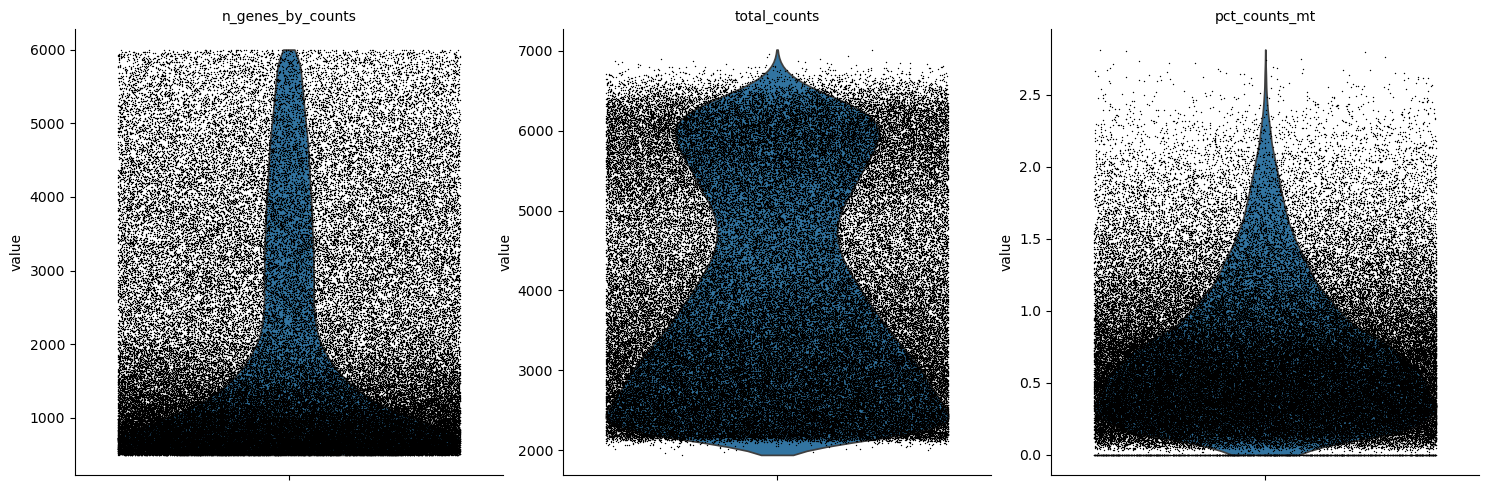

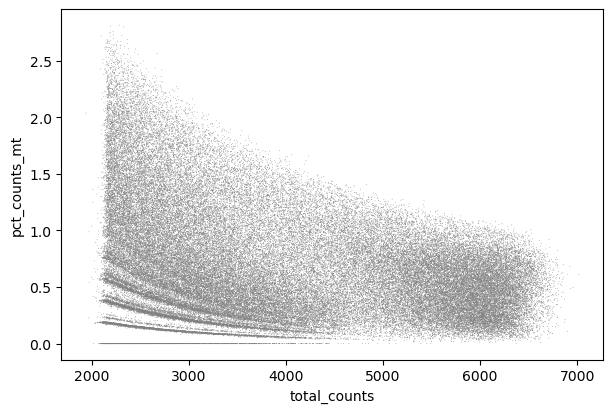

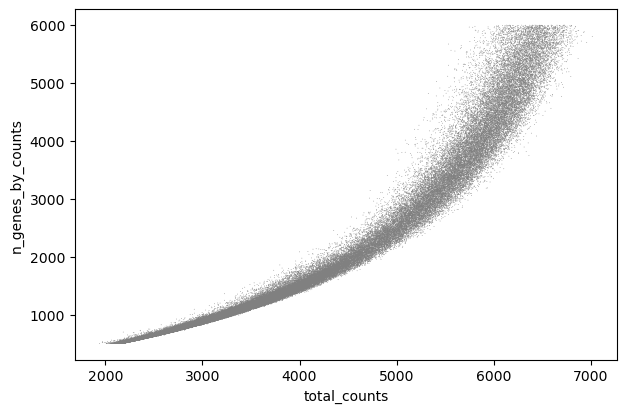

In [22]:
# 6. QC filtering
# mark the mitochondrial genes
# 'MT' for humans in most cases
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

# calculate QC matrix
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, inplace=True)
print("Number of mitochondrial genes detected:", adata.var["mt"].sum())
print("Original cell number:", adata.n_obs)

# set thresholds for QC
min_genes = 200 # filter out low-quality cells that have too few detected genes.
# intended to filter out doublets
# use 6000 instead of MAD (median absolute deviation)-determined ones (usually stricter) 
# to avoid filtering out active brain cells misclassified as mutiplets
max_genes = 6000 
max_counts = 20000
max_mt = 10 # filter out cells with high %mt, though it's a snRNA-seq database    

# apply QC filter
adata = adata[adata.obs["n_genes_by_counts"] > min_genes, :]
adata = adata[adata.obs["n_genes_by_counts"] < max_genes, :]
adata = adata[adata.obs["total_counts"] < max_counts, :]
adata = adata[adata.obs["pct_counts_mt"] < max_mt, :]

print("After QC filtering:", adata.n_obs)

# QC plots
sc.pl.violin(adata,["n_genes_by_counts","total_counts","pct_counts_mt"],jitter=0.4,multi_panel=True,save="qc_violin")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt",save="qc_scatter_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts",save = "qc_scatter_genes")

In [7]:
# 7. Normalize & HVGs

# normalize to make possible comparison of expression levels between cells
sc.pp.normalize_total(adata, target_sum=1e4)
# apply a log transformation to the normalized data
sc.pp.log1p(adata)

# highly variable genes (HVGs) selection
# identify the top 3000 HVGs 
# that are driving variations between cell types
# to reduce noise for the following steps
n_top_genes = 3000
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, subset=True, inplace = True)
print("Using HVGs shape:", adata.shape)


normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes


/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using HVGs shape: (97893, 3000)


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:16)


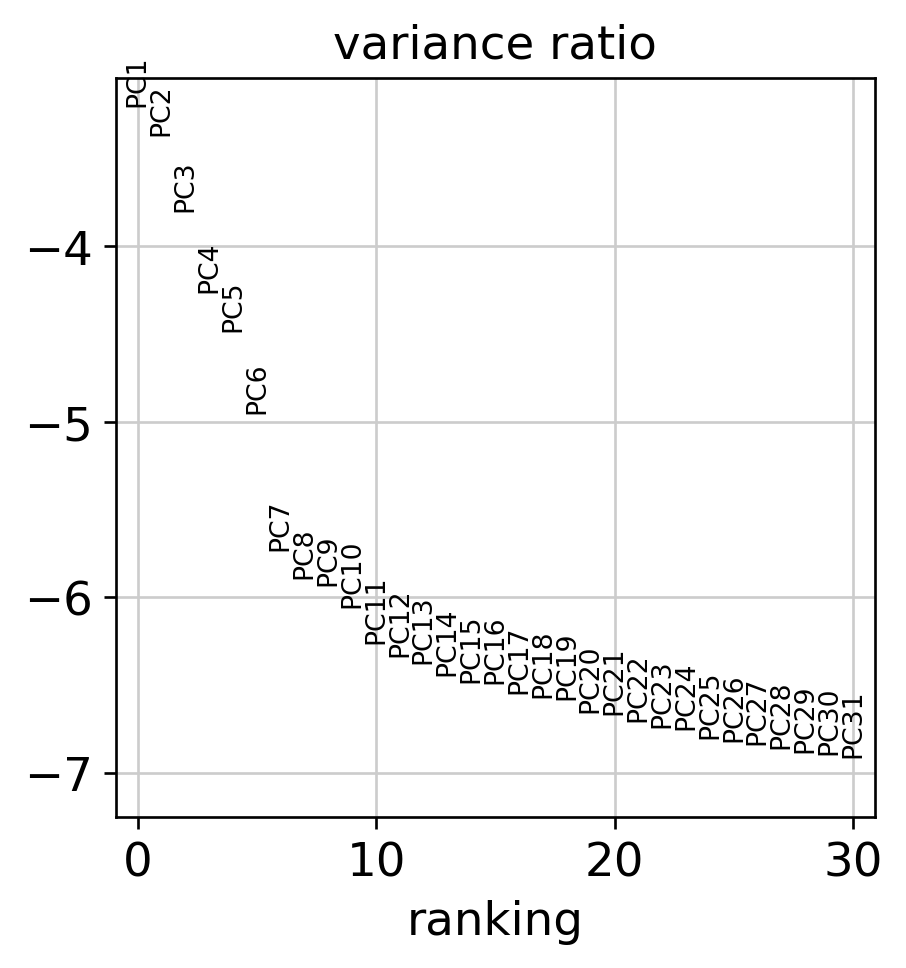

In [8]:
# 8. plot principal component analysis (PCA) variance ratio diagram
# finds the main axes of variation in the data
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True,save = "pca_variance_ratio")


computing neighbors
    using 'X_pca' with n_pcs = 30


/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:15)


/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


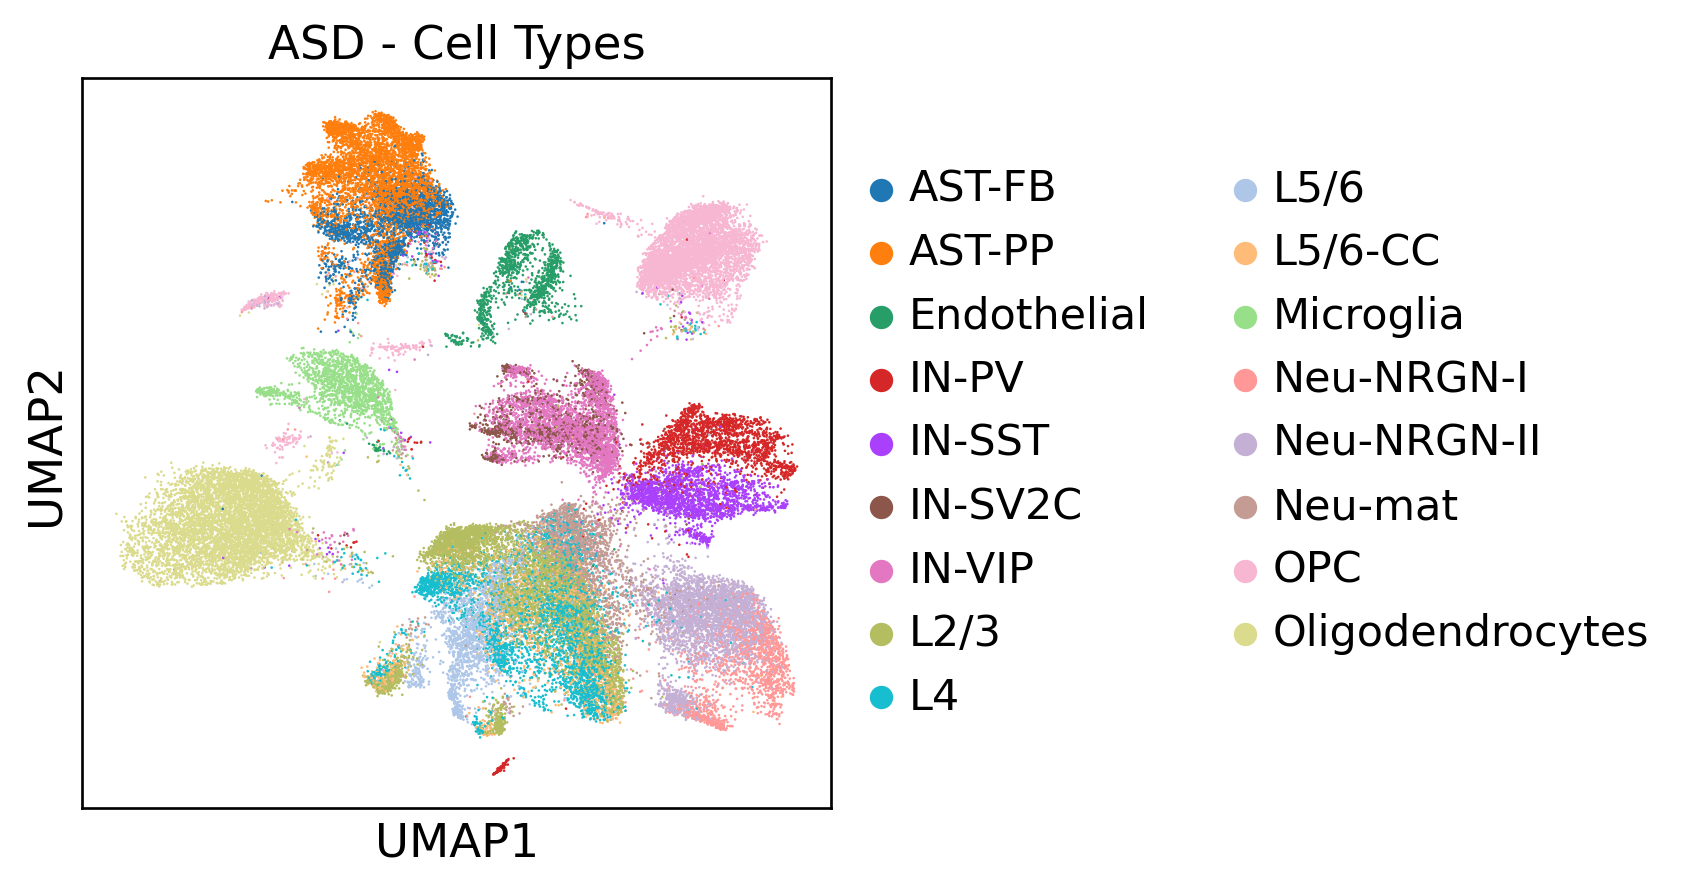

In [9]:
# 9. form cell neighbors and UMAP for both control and ASD groups
# to classify similar cells with shared PCs as neighbors

# n_neighbors refers to the number of nearest neighbors to use when constructing the neighborhood graph
n_neighbors = 30

# n_pcs refers to the number of principal components to use
# identify the elbow point, at which the curve of PCA variance ratio starts to lay off
# this point could help determine n_pcs
n_pcs = 30
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs)

# to keep the gene expression-based neighborhood graph while computing a new graph based on other features
# eg. SASP score in the following analysis
adata.obsp['distances_gex'] = adata.obsp['distances'].copy()
adata.obsp['connectivities_gex'] = adata.obsp['connectivities'].copy()

# compute UMAP embedding first
sc.tl.umap(adata)

# classify the data based on diagnosis to plot 2 seperate umap for both groups
adata_asd = adata[adata.obs['diagnosis'] == 'ASD']
adata_control = adata[adata.obs['diagnosis'] == 'Control']

sc.pl.umap(adata_asd, color=["cluster"],title='ASD - Cell Types',save = 'UMAP_Cell_Types')


/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/zikoole/miniconda3/envs/asd_sen/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


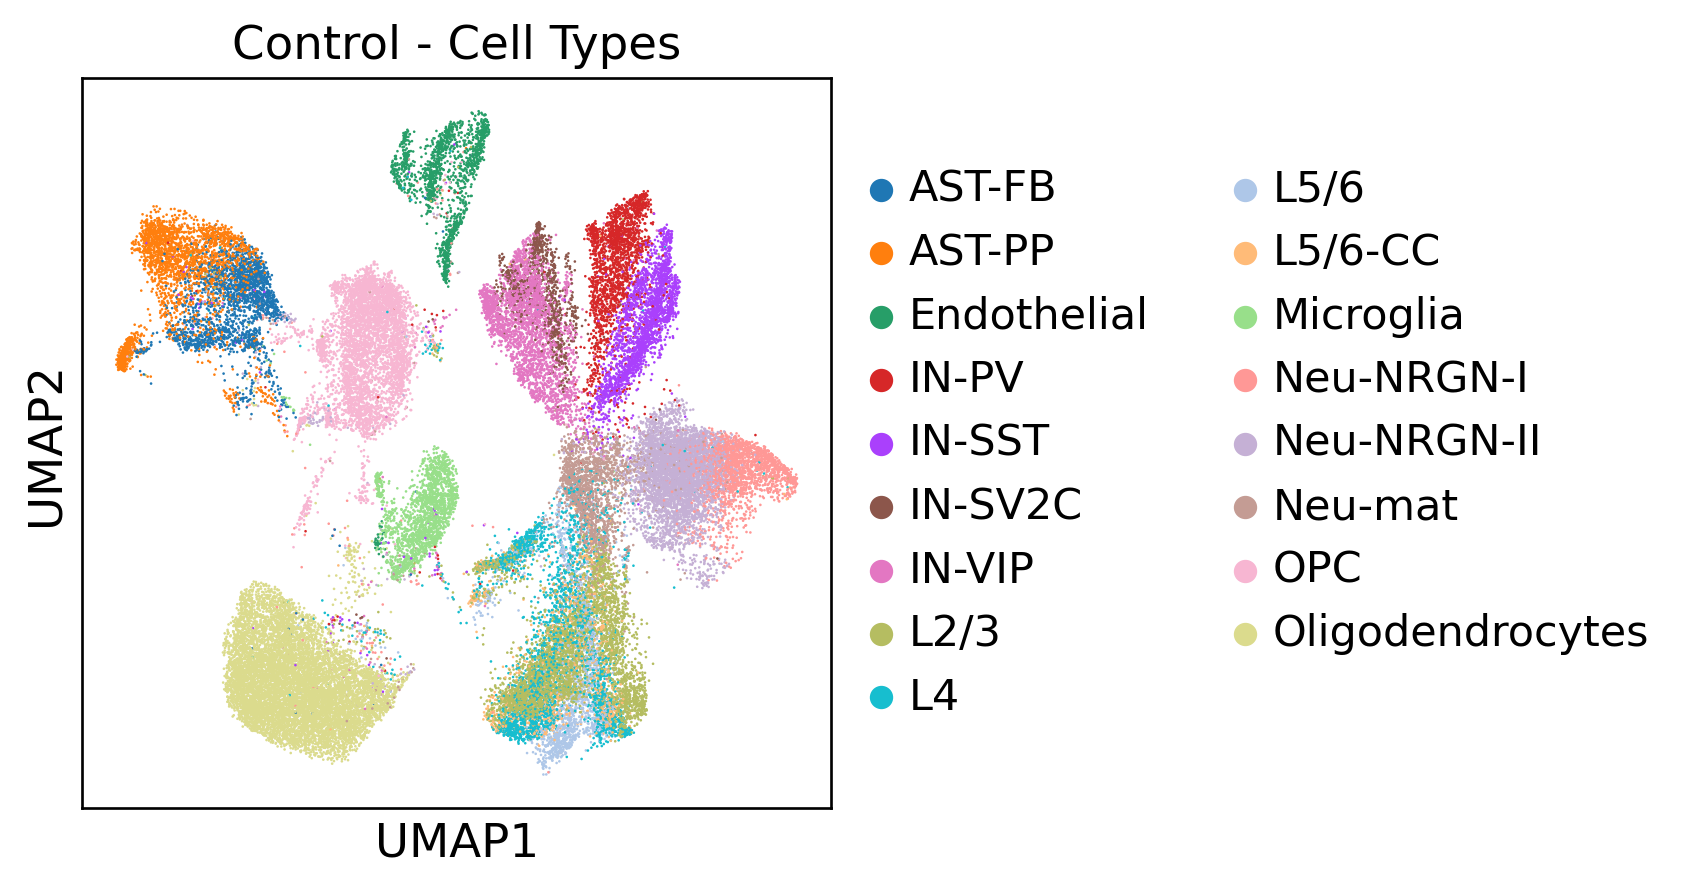

In [12]:
sc.pl.umap(adata_control, color=["cluster"],title='Control - Cell Types')

In [10]:
# 10. import and parse SenMayo set (gmt file) as SASP gene set 

def parse_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            name = parts[0]
            genes = parts[2:]
            gene_sets[name] = genes
    return gene_sets

gene_sets = parse_gmt(senmayo_path)
senmayo_genes = list(gene_sets.values())[0]

In [11]:
# 11. calculate SASP score
def resolve_genes(glist): return [g for g in glist if g in adata.var_names]

sasp_found = resolve_genes(senmayo_genes)
print("SASP found:", sasp_found)

# Only calculate score if sufficient genes (>=3) are found
if len(sasp_found)>=3:
    sc.tl.score_genes(adata, sasp_found, score_name="SASP_score", use_raw=False)

SASP found: ['ANGPTL4', 'AXL', 'C3', 'CCL2', 'CCL20', 'CCL3', 'CCL4', 'CCL8', 'CD55', 'CD9', 'CSF1', 'CTSB', 'CXCL1', 'CXCL10', 'CXCL16', 'CXCL2', 'CXCL3', 'CXCL8', 'FGF2', 'GEM', 'IGFBP5', 'IGFBP7', 'IL18', 'IL1A', 'IL1B', 'IL6', 'IL6ST', 'ITGA2', 'JUN', 'LCP1', 'MMP14', 'PECAM1', 'PLAT', 'SELPLG', 'SERPINE2', 'SPP1', 'TNF', 'TNFRSF1B', 'VEGFA']
computing score 'SASP_score'
    finished: added
    'SASP_score', score of gene set (adata.obs).
    834 total control genes are used. (0:00:04)


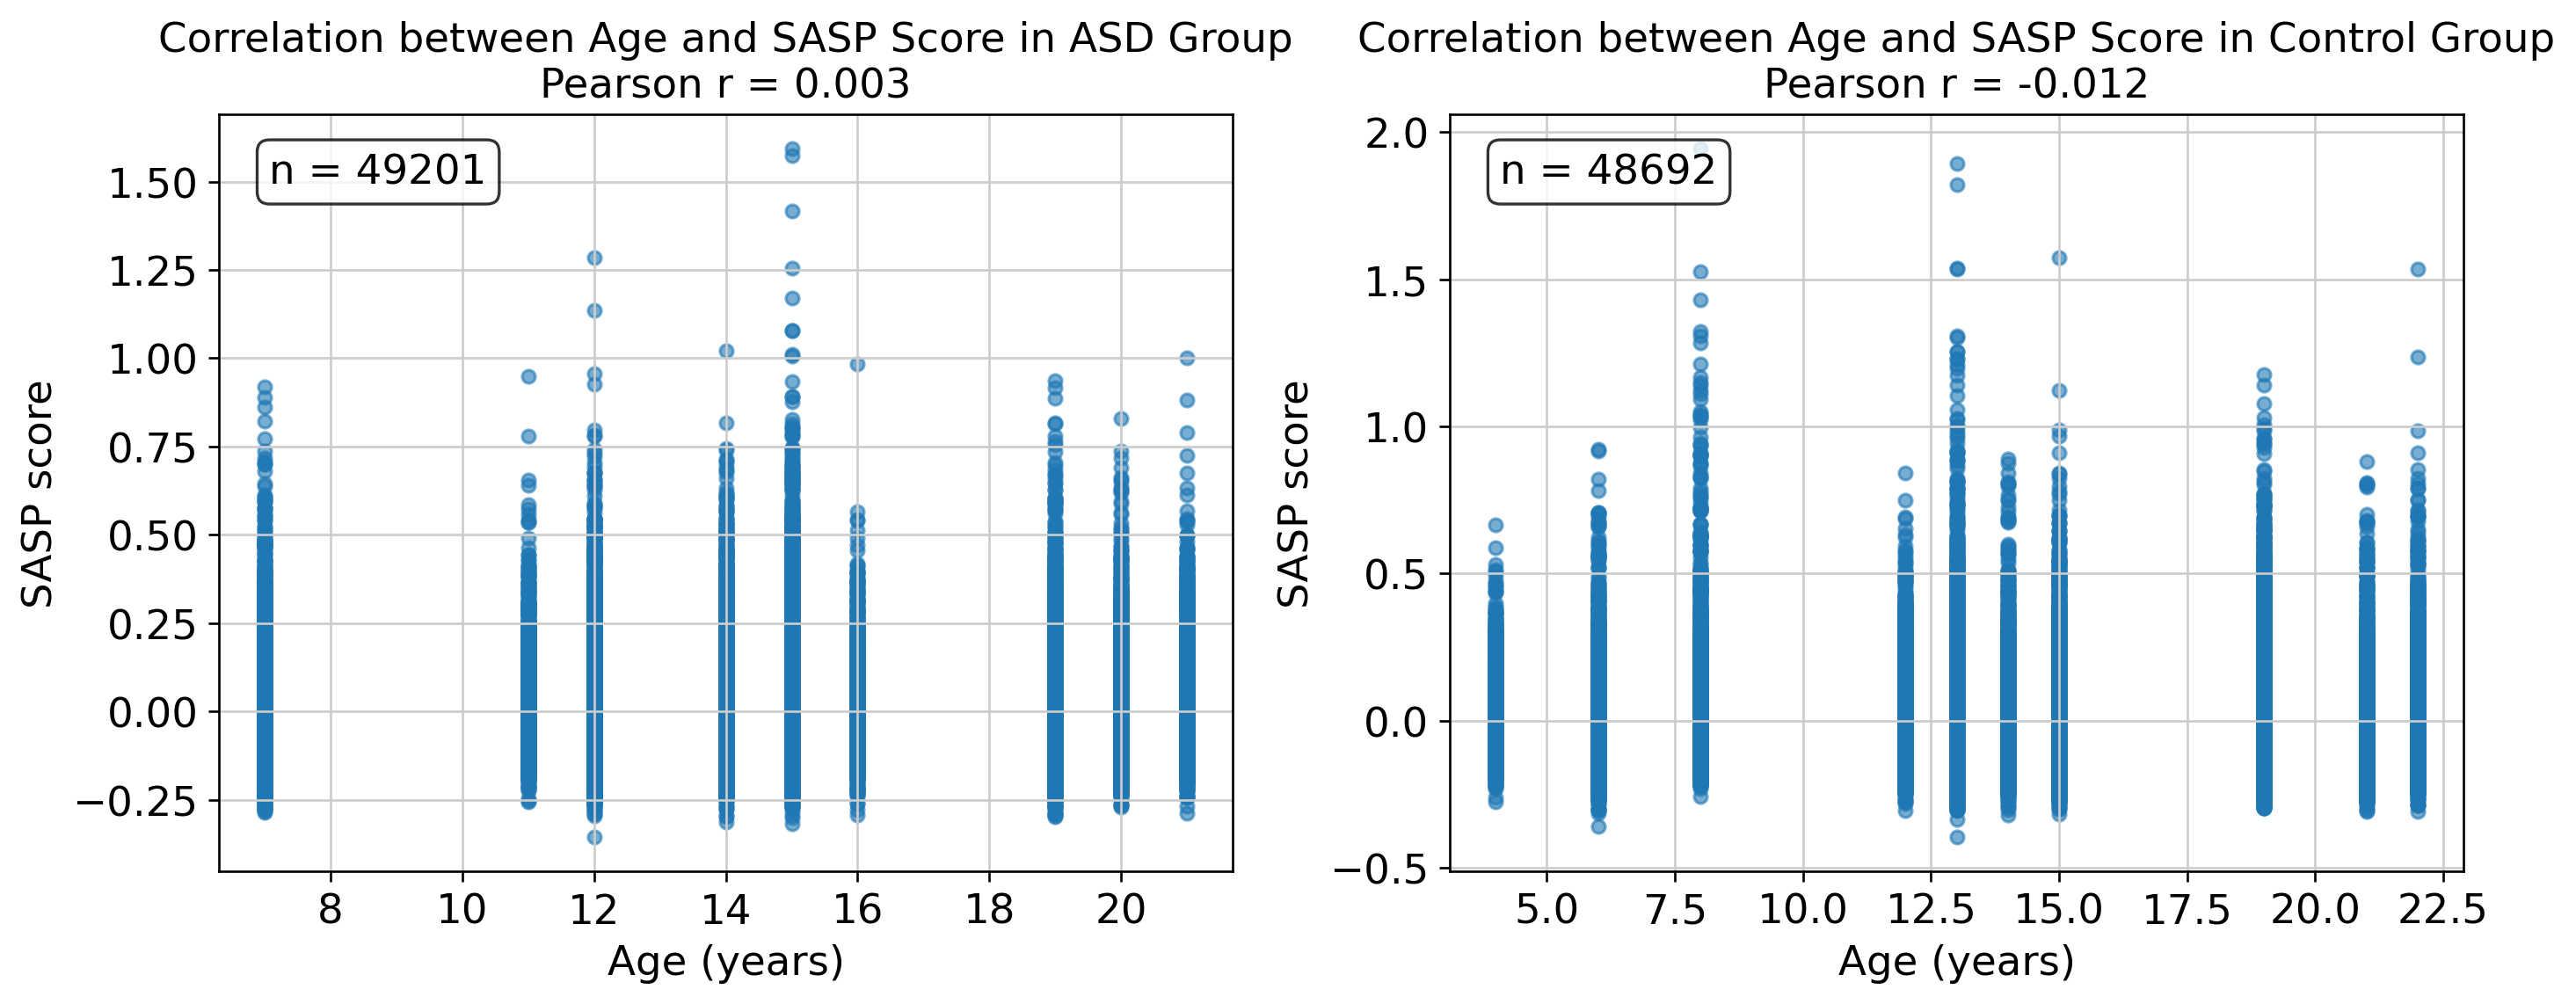

In [32]:
# 12. verify age as a potential confounding factor
# aging is often linked to cellular senescence while not being strictly controlled in this dataset
# while the participants are fairly young, a verification of such confounding factor is still needed to avoid misleading results

adata.obs['age'] = pd.to_numeric(adata.obs['age'], errors='coerce')
    
# set up a single figure with subplots for both ASD and control groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
for idx, (diag, label) in enumerate([('ASD', 'ASD'), ('Control', 'Control')]):
    sub = adata.obs[adata.obs['diagnosis'] == diag].dropna(subset=['age', 'SASP_score'])
        
    # calculate Pearson correlation coefficient r
    r, p = stats.pearsonr(sub['age'], sub['SASP_score'])
    correlation_text = f"Pearson r = {r:.3f}"
        
    # Create regression plot
    sns.regplot(x='age', y='SASP_score', data=sub, 
                   scatter_kws={'s': 20, 'alpha': 0.6}, 
                   ax=axes[idx], 
                fit_reg=False)
        
    # Customize subplot
    axes[idx].set_title(f"Correlation between Age and SASP Score in {label} Group\n{correlation_text}")
    axes[idx].set_xlabel("Age (years)")
    axes[idx].set_ylabel("SASP score")
        
    # Add sample size annotation
    axes[idx].annotate(f'n = {sub.shape[0]}', 
                       xy=(0.05, 0.95), 
                       xycoords='axes fraction',
                       ha='left', va='top',
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR,"age_vs_SASP.pdf")
plt.show()

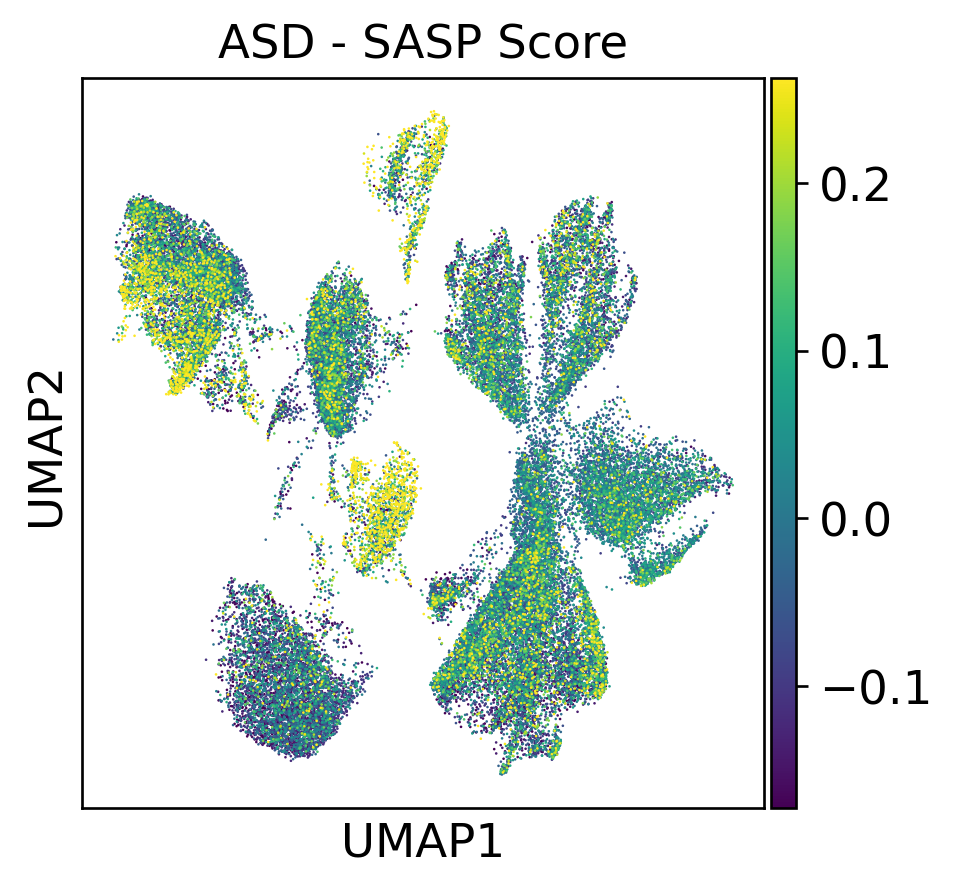

In [17]:
# 13. plot UMAP indicating SASP score for ASD and Control
adata_asd = adata[adata.obs['diagnosis'] == 'ASD'].copy()
adata_control = adata[adata.obs['diagnosis'] == 'Control'].copy()

# set global_vmin & vmax that excludes extreme value
# to make sure the graph has more observable color variance
global_vmin = adata.obs['SASP_score'].quantile(0.05)
global_vmax = adata.obs['SASP_score'].quantile(0.95)
sc.pl.umap(adata_asd, color='SASP_score', cmap='viridis', vmin=global_vmin, vmax=global_vmax, title='ASD - SASP Score', save = 'UMAP_SASP')


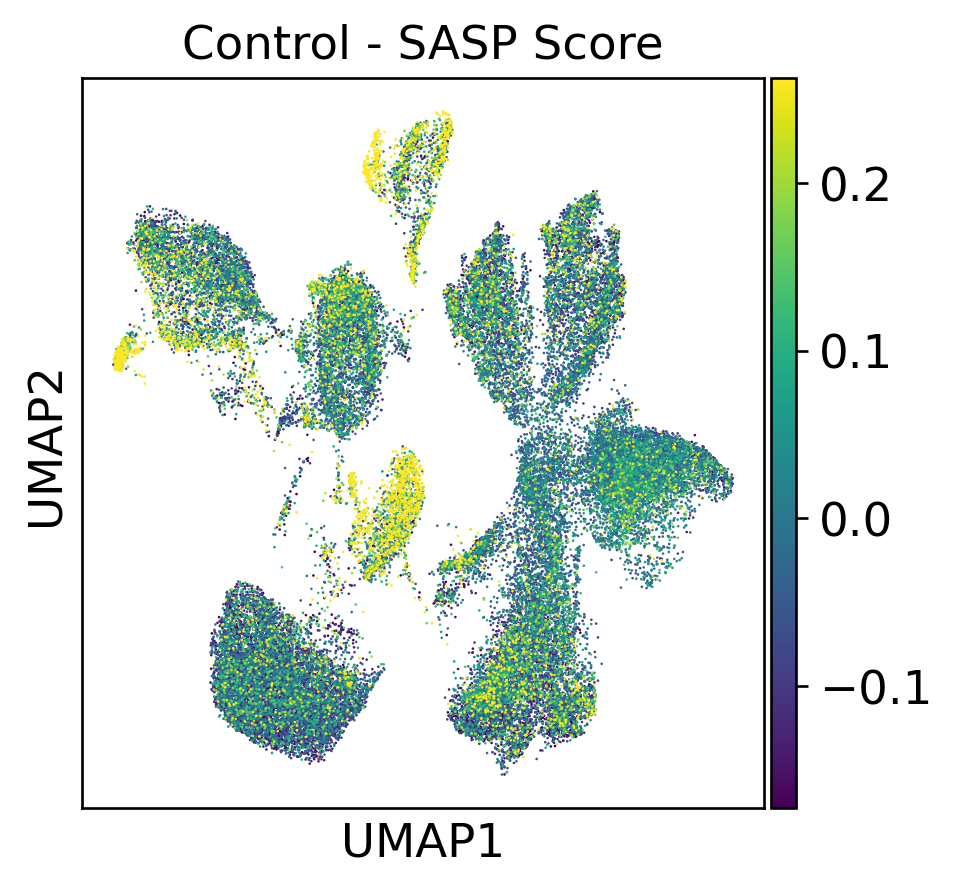

In [18]:
sc.pl.umap(adata_control, color='SASP_score', cmap='viridis', vmin=global_vmin, vmax=global_vmax, 
           title='Control - SASP Score')

In [12]:
# 13. ran Mann-Whitney U test and calculate effect size using Cohen's d
results = []
cell_types = adata.obs['cluster'].unique().tolist()

for ct in cell_types:
    sub = adata.obs[adata.obs['cluster'] == ct]
    group_asd = sub.loc[sub['diagnosis'] == 'ASD', 'SASP_score'].values
    group_ctrl = sub.loc[sub['diagnosis'] == 'Control', 'SASP_score'].values
    # Skip cell types with insufficient samples in either grou
    if len(group_asd) < 5 or len(group_ctrl) < 5:
        continue
    # ran Mann-Whitney U test
    try:
        ustat, pval = stats.mannwhitneyu(group_asd, group_ctrl, alternative='two-sided')
    except Exception as e:
        print(f"Error in Mann-Whitney U test for {ct}: {e}")
        continue
    # calculate effect size using Cohen's d
    m1, m2 = np.mean(group_asd), np.mean(group_ctrl)
    s1, s2 = np.std(group_asd, ddof=1), np.std(group_ctrl, ddof=1)
    n1, n2 = len(group_asd), len(group_ctrl)
    pooled_sd = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / (n1 + n2 - 2)) if (n1 + n2 - 2) > 0 else np.nan
    cohens_d = (m1 - m2) / pooled_sd if pooled_sd > 0 else np.nan
    results.append({
        'cell_type': ct,
        'n_ASD': n1,
        'n_Control': n2,
        'mean_ASD': m1,
        'mean_Control': m2,
        'p_value': pval,
        'cohen_d': cohens_d
    })
stats_df = pd.DataFrame(results).sort_values('p_value')
# use Benjamini-Hochberg FDR correction to avoid false positive
# important when involve multiple cell types
_, stats_df['p_adj'], _, _ = multipletests(stats_df['p_value'], method='fdr_bh')
stats_df.to_csv(os.path.join(TAB_DIR, "sasp_celltype_stats.csv"), index=False)
print("Wrote stats to:", os.path.join(TAB_DIR, "sasp_celltype_stats.csv"))


Wrote stats to: ../results/sasp_celltype_stats.csv


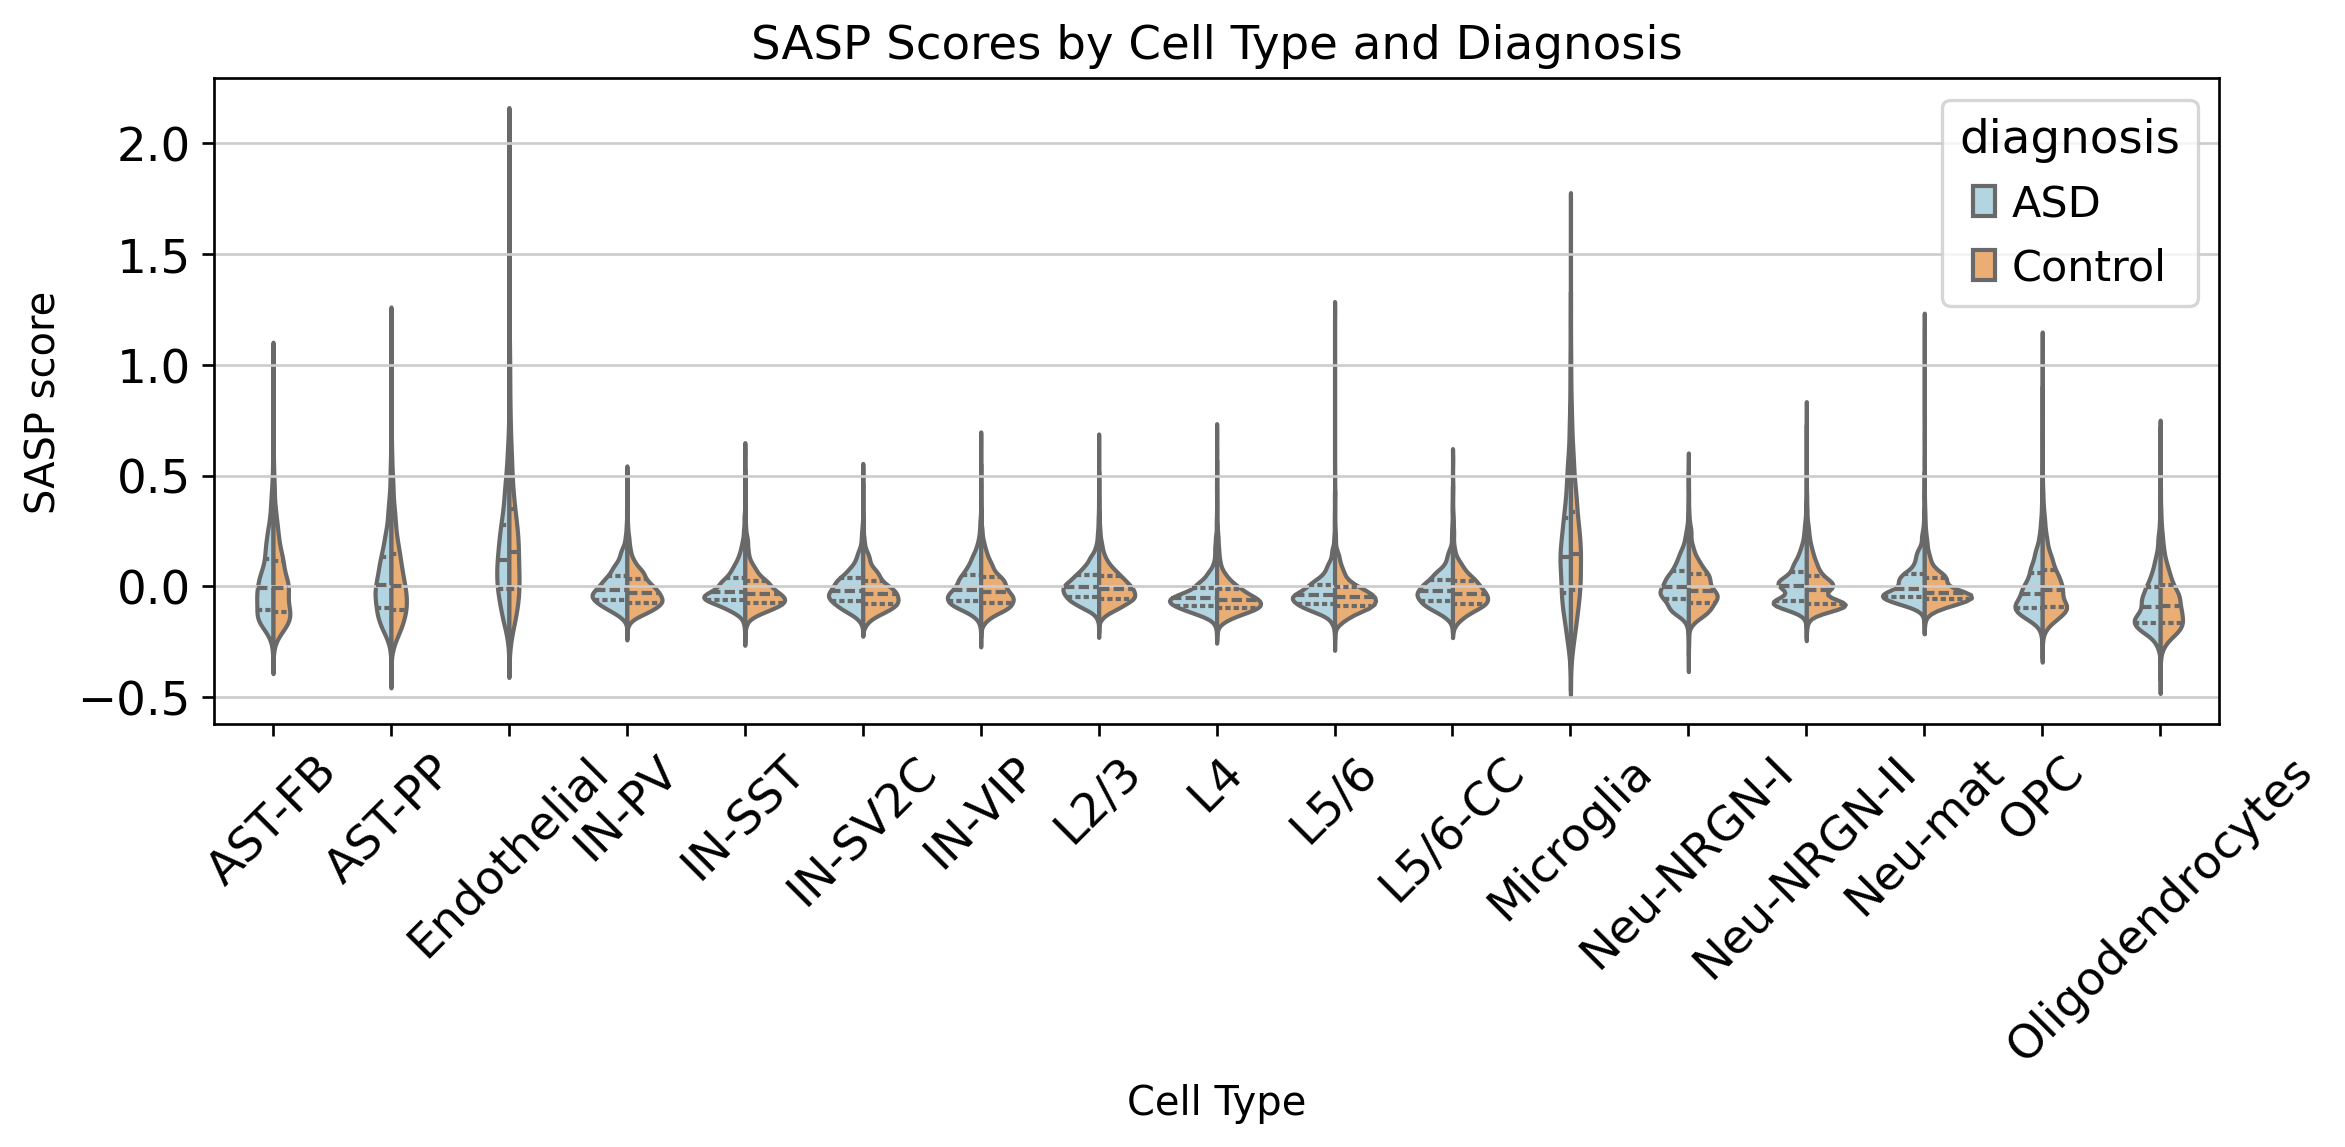

In [36]:
# 14. visualize the SASP score difference between cell types and diagnosis
plt.figure(figsize=(10,5))
sns.violinplot(
    data=adata.obs,
    x="cluster", 
    y="SASP_score", 
    hue="diagnosis", 
    split=True, 
    inner="quartile",
    palette=["#ABD9E9", "#FDAE61"]
)

plt.xlabel("Cell Type", fontsize=12)
plt.ylabel('SASP score', fontsize=12)
plt.xticks(rotation=45)
plt.title("SASP Scores by Cell Type and Diagnosis")
plt.tight_layout()
plt.savefig(FIG_DIR, "violin_SASP)
plt.show()


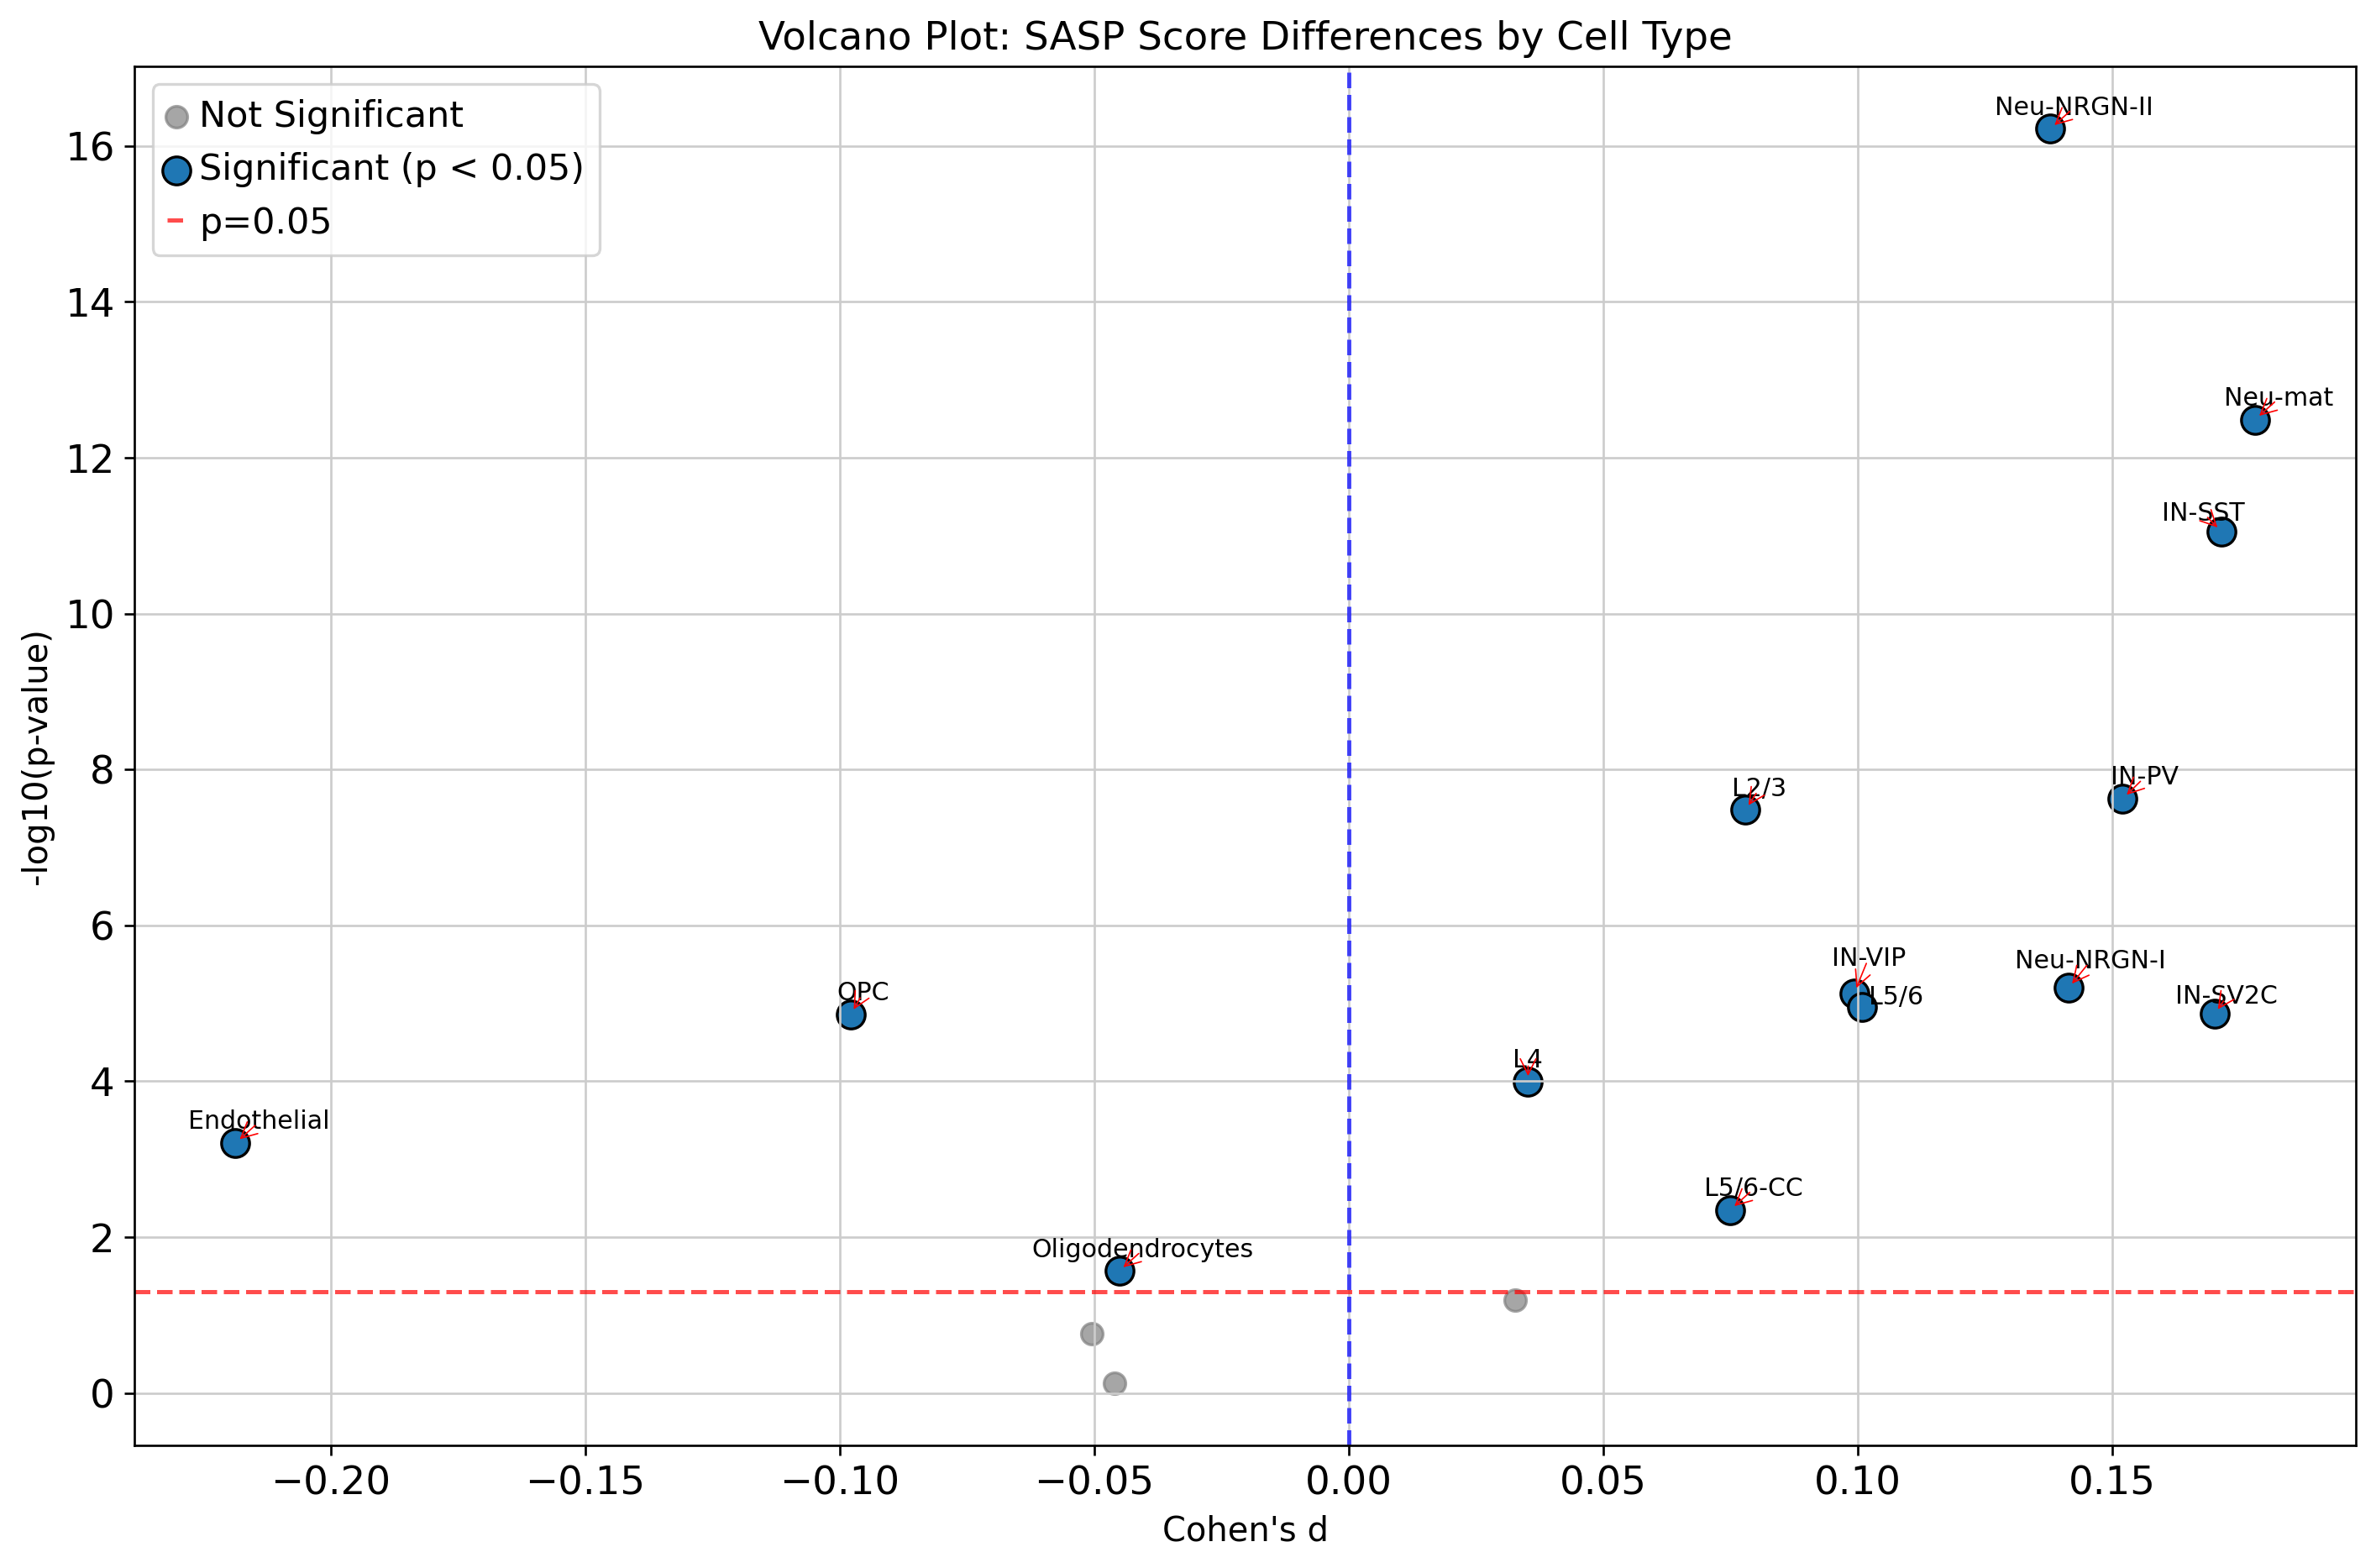

In [14]:
# 15. visualize the p value and cohen's d using a volcano plot
plt.figure(figsize=(12, 8))

# separate significant and non-significant points by p values
significant = stats_df[stats_df['p_value'] < 0.05]
non_significant = stats_df[stats_df['p_value'] >= 0.05]

# Plot non-significant points
plt.scatter(non_significant['cohen_d'], 
           -np.log10(non_significant['p_value']),
           c='gray', s=60, alpha=0.7,
           label='Not Significant')

# Plot significant points with color mapping
scatter = plt.scatter(significant['cohen_d'], 
                     -np.log10(significant['p_value']),
                      
                     s=100,
                     edgecolors='black',
                     linewidth=1,
                     label='Significant (p < 0.05)')



# Add reference lines
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', alpha=0.7, label='p=0.05')
plt.axvline(x=0, color='blue', linestyle='--', alpha=0.7)

# Add labels only for significant points to reduce clutter
texts = []
for i, row in significant.iterrows():
    texts.append(plt.text(row['cohen_d'], 
                         -np.log10(row['p_value']), 
                         row['cell_type'],
                         fontsize=9,
                         ha='center',
                         va='bottom'))

# Adjust text labels to prevent overlap
adjust_text(texts,
            arrowprops=dict(arrowstyle='->', color='red', lw=0.5),
            force_text=(0.2, 0.2),
            expand_points=(2, 2),
            expand_text=(1.2, 1.2),
            only_move={'points':'y', 'text':'y'})

# Add labels and title
plt.xlabel("Cohen's d", fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.title('Volcano Plot: SASP Score Differences by Cell Type', fontsize=14)
plt.legend()
plg.savefig(FIG_DIR,"Volcano_SASP_comparison")
plt.tight_layout()
plt.show()